# Notebook 4: Fraud Detection

Insurance fraud costs the industry an estimated $308.6 billion a year, and investigation resources are
always limited. Gulf Crest's Special Investigations Unit (SIU) cannot review every claim, so a model that
ranks claims by fraud likelihood lets investigators focus their time where it matters most.

This notebook covers, in order:
1. Preparing claim-level features for a fraud classifier, including two engineered from repair cost records
2. Why accuracy is the wrong metric for this problem, and what to use instead
3. A baseline classifier, then several ways of correcting for class imbalance: class weighting, SMOTE,
   a recall-targeted decision threshold, and a gradient boosting model with a tuned threshold of its own
4. Isolation Forest: an unsupervised approach that does not require fraud labels at all
5. Comparing all approaches and deciding how they would be used together

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest, HistGradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve,
    f1_score, precision_score, recall_score, accuracy_score, auc
)
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 20)

DATA_DIR = "../04_Datasets/"
policies      = pd.read_csv(DATA_DIR + "01_policies.csv")
claims        = pd.read_csv(DATA_DIR + "02_claims.csv")
fraud_labels  = pd.read_csv(DATA_DIR + "06_fraud_labels.csv")
repair_costs  = pd.read_csv(DATA_DIR + "05_repair_costs.csv")

print("Data loaded.")

Data loaded.


## 1. Building the Feature Set

Each claim is joined to its policy (for property characteristics) and to its fraud label (where one exists).
Two engineered fields are added: `property_age_at_loss` (older properties can carry different risk) and
`days_to_report` (the gap between the date of loss and the date the claim was reported; an unusually long
or unusually short gap is a pattern SIU investigators already look at in practice).

In [2]:
data = claims.merge(policies, on="policy_id").merge(fraud_labels, on="claim_id", how="left")

data["date_of_loss"] = pd.to_datetime(data["date_of_loss"])
data["date_reported"] = pd.to_datetime(data["date_reported"])
data["policy_start_date"] = pd.to_datetime(data["policy_start_date"])

data["days_to_report"] = (data["date_reported"] - data["date_of_loss"]).dt.days
data["property_age_at_loss"] = data["date_of_loss"].dt.year - data.get("year_built", data["date_of_loss"].dt.year)
if "year_built" in data.columns:
    data["property_age_at_loss"] = data["date_of_loss"].dt.year - data["year_built"]

print("Combined table shape:", data.shape)
data[["claim_id", "reported_severity", "days_to_report", "is_fraud"]].head()

Combined table shape: (2883, 24)


,claim_id,reported_severity,days_to_report,is_fraud
0,CLM-000001,8689.85,6,0.0
1,CLM-000002,858.40,6,1.0
2,CLM-000003,10464.68,1,0.0
3,CLM-000004,25062.11,0,NaN
4,CLM-000005,13536.78,5,1.0


## 2. Two More Features, Built From Data We Already Have

The features so far only describe the property and the claim on paper. Two more fields, drawn from the
repair cost line items already collected in `05_repair_costs.csv`, are worth adding before training anything:

- **`repair_line_items`**: how many separate repair categories were billed on a claim. A claim broken into
  an unusually large number of line items is a pattern SIU investigators already watch for, since it can
  be a way of padding a claim with charges that would look suspicious as a single large one.
- **`cost_overrun_ratio`**: for claims that have settled, how far the actual repair cost came in above (or
  below) what was originally estimated. A large overrun is not proof of anything on its own, but it is a
  legitimate signal worth giving the model, alongside everything else.

`cost_overrun_ratio` can only be computed for claims that have already settled (about 16% of repair line
items have an `actual_cost` filled in), so it is missing for the rest. Rather than dropping those rows or
inventing a value, the missing case is treated as its own piece of information: a placeholder value is used
together with a companion flag column that tells the model "this ratio is not yet known," so the model can
treat an unresolved claim differently from a claim confirmed to be right on budget.

In [3]:
repair_summary = repair_costs.groupby("claim_id").agg(
    repair_line_items=("repair_category", "count"),
    estimated_total=("estimated_cost", "sum"),
    actual_total=("actual_cost", "sum"),
).reset_index()

repair_summary["cost_overrun_ratio"] = (
    (repair_summary["actual_total"] - repair_summary["estimated_total"]) / repair_summary["estimated_total"]
)
repair_summary["cost_overrun_known"] = repair_summary["cost_overrun_ratio"].notna().astype(int)
repair_summary["cost_overrun_ratio"] = repair_summary["cost_overrun_ratio"].fillna(0.0)

data = data.merge(
    repair_summary[["claim_id", "repair_line_items", "cost_overrun_ratio", "cost_overrun_known"]],
    on="claim_id", how="left"
)
# a handful of claims have no repair cost record at all yet; treat that the same way as "not yet known"
data["repair_line_items"] = data["repair_line_items"].fillna(0)
data["cost_overrun_ratio"] = data["cost_overrun_ratio"].fillna(0.0)
data["cost_overrun_known"] = data["cost_overrun_known"].fillna(0).astype(int)

# severity relative to the property's insured value: a claim close to a total loss behaves
# differently from a small claim on a large policy
data["severity_to_tiv_ratio"] = data["reported_severity"] / data["total_insured_value"]

print(f"Claims with a known cost overrun ratio: {data['cost_overrun_known'].sum()} of {len(data)}")
data[["claim_id", "repair_line_items", "cost_overrun_ratio", "cost_overrun_known", "severity_to_tiv_ratio"]].head()

Claims with a known cost overrun ratio: 2601 of 2883


,claim_id,repair_line_items,cost_overrun_ratio,cost_overrun_known,severity_to_tiv_ratio
0,CLM-000001,1.0,0.177881,1,0.055279
1,CLM-000002,1.0,0.123014,1,0.003345
2,CLM-000003,0.0,0.000000,0,0.031587
3,CLM-000004,1.0,0.011631,1,0.040416
4,CLM-000005,0.0,0.000000,0,0.029441


## 3. The Labeled Subset

Only claims the SIU has already investigated carry a value in `is_fraud`. Everything else is `NaN`, meaning
"not yet reviewed," not "confirmed not fraud." A supervised classifier can only be trained on the labeled
subset, since it needs to know the correct answer during training.

In [4]:
labeled = data.dropna(subset=["is_fraud"]).copy()
labeled["is_fraud"] = labeled["is_fraud"].astype(int)

print(f"Labeled claims: {len(labeled)} of {len(data)} total ({len(labeled) / len(data):.1%})")
print()
print("Fraud rate within the labeled subset:")
print(labeled["is_fraud"].value_counts(normalize=True).round(3))

Labeled claims: 1656 of 2883 total (57.4%)

Fraud rate within the labeled subset:
is_fraud
0    0.85
1    0.15
Name: proportion, dtype: float64


Roughly 15% of investigated claims were confirmed fraudulent. That is a meaningful imbalance: a model
that predicts "not fraud" for every single claim would still be correct about 85% of the time, while
catching zero actual fraud. This is exactly why accuracy is the wrong metric here, and it is worth
demonstrating directly before building anything more sophisticated.

In [5]:
numeric_features = [
    "total_insured_value", "reported_severity", "days_to_report", "property_age_at_loss",
    "severity_to_tiv_ratio", "repair_line_items", "cost_overrun_ratio",
]
categorical_features = [
    "coastal_zone_flag", "construction_type", "coverage_type", "cause_of_loss",
    "is_catastrophe_flag", "cost_overrun_known",
]
target = "is_fraud"

X = labeled[numeric_features + categorical_features]
y = labeled[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training rows: {len(X_train)}  |  Test rows: {len(X_test)}")
print(f"Fraud rate in training set: {y_train.mean():.1%}  |  Fraud rate in test set: {y_test.mean():.1%}")

Training rows: 1242  |  Test rows: 414
Fraud rate in training set: 15.0%  |  Fraud rate in test set: 15.0%


## 4. A Naive Baseline: Predict "Not Fraud" for Everything

Before training any model, it helps to see what a model that ignores the data entirely would score. This
sets the floor that a real model needs to beat.

In [6]:
naive_predictions = np.zeros_like(y_test)

print(f"Accuracy of predicting 'not fraud' for every claim: {accuracy_score(y_test, naive_predictions):.1%}")
print(f"Recall on actual fraud cases: {recall_score(y_test, naive_predictions):.1%}")
print(f"Precision on actual fraud cases: {precision_score(y_test, naive_predictions, zero_division=0):.1%}")

Accuracy of predicting 'not fraud' for every claim: 85.0%
Recall on actual fraud cases: 0.0%
Precision on actual fraud cases: 0.0%


Accuracy near 85% looks respectable at a glance, but recall is 0%: every fraudulent claim in the test
set would slip through undetected. This is the core lesson of this notebook. **Under class imbalance,
accuracy can be high while the model is worthless for the task it exists to do.** Precision, recall, and
F1 (their combined score) are used instead for the rest of this notebook.

- **Precision**: of the claims flagged as fraud, what fraction actually were fraud? Low precision wastes
  investigator time on false alarms.
- **Recall**: of the claims that actually were fraud, what fraction did the model catch? Low recall means
  fraud slips through.
- **F1**: the balance of the two, useful as a single number for comparing models.

## 5. Baseline Classifier: Logistic Regression, No Imbalance Correction

A logistic regression is trained first with no special handling for the class imbalance, exactly as a
first attempt often looks in practice.

In [7]:
preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ("num", StandardScaler(), numeric_features),
])

baseline_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42)),
])

baseline_pipeline.fit(X_train, y_train)
baseline_preds = baseline_pipeline.predict(X_test)

print("Baseline logistic regression (no imbalance correction):")
print(classification_report(y_test, baseline_preds, target_names=["Not Fraud", "Fraud"], zero_division=0))

Baseline logistic regression (no imbalance correction):
              precision    recall  f1-score   support

   Not Fraud       0.85      1.00      0.92       352
       Fraud       0.00      0.00      0.00        62

    accuracy                           0.85       414
   macro avg       0.43      0.50      0.46       414
weighted avg       0.72      0.85      0.78       414



Recall on the fraud class is typically weak here: the model, trained on a dataset that is mostly
"not fraud," learns that predicting "not fraud" is usually the safe bet. Two corrections are tried next.

## 6. Correction 1: Class Weighting

The simplest fix requires no changes to the data at all. `class_weight="balanced"` tells the model to
penalize a missed fraud case more heavily than a false alarm, proportional to how rare fraud is in the
training data.

In [8]:
weighted_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")),
])

weighted_pipeline.fit(X_train, y_train)
weighted_preds = weighted_pipeline.predict(X_test)

print("Logistic regression with class_weight='balanced':")
print(classification_report(y_test, weighted_preds, target_names=["Not Fraud", "Fraud"]))

Logistic regression with class_weight='balanced':
              precision    recall  f1-score   support

   Not Fraud       0.88      0.51      0.65       352
       Fraud       0.18      0.60      0.27        62

    accuracy                           0.53       414
   macro avg       0.53      0.56      0.46       414
weighted avg       0.77      0.53      0.59       414



## 7. Correction 2: SMOTE (Synthetic Minority Oversampling)

SMOTE generates synthetic fraud examples by interpolating between real fraud cases and their nearest
neighbors in feature space, rather than simply duplicating existing rows. It is applied only to the
training data (never the test set, which must stay untouched to give an honest read of performance).

In [9]:
X_train_encoded = preprocessor.fit_transform(X_train)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_encoded, y_train)

print(f"Training rows before SMOTE: {len(y_train)}  (fraud rate {y_train.mean():.1%})")
print(f"Training rows after SMOTE:  {len(y_train_resampled)}  (fraud rate {y_train_resampled.mean():.1%})")

smote_model = LogisticRegression(max_iter=1000, random_state=42)
smote_model.fit(X_train_resampled, y_train_resampled)

X_test_encoded = preprocessor.transform(X_test)
smote_preds = smote_model.predict(X_test_encoded)

print()
print("Logistic regression trained on SMOTE-resampled data:")
print(classification_report(y_test, smote_preds, target_names=["Not Fraud", "Fraud"]))

Training rows before SMOTE: 1242  (fraud rate 15.0%)
Training rows after SMOTE:  2112  (fraud rate 50.0%)

Logistic regression trained on SMOTE-resampled data:


              precision    recall  f1-score   support

   Not Fraud       0.90      0.45      0.60       352
       Fraud       0.19      0.73      0.30        62

    accuracy                           0.50       414
   macro avg       0.55      0.59      0.45       414
weighted avg       0.80      0.50      0.56       414



## 8. Pushing Recall Further: a Recall-Targeted Decision Threshold

SMOTE's 73% recall is a real improvement over the uncorrected baseline, but for an SIU that treats a missed
fraud case as more expensive than an extra investigation, letting roughly a quarter of fraud slip through is
still a lot. Rather than reach for a heavier resampling technique, the same SMOTE-trained model can be pushed
further with a second methodology change: choosing the decision threshold to explicitly guarantee a minimum
recall, then getting the best precision the model can still offer at that recall level. Setting a required
recall (or "sensitivity") floor and finding the operating point that meets it is standard practice in
domains where missing a positive case is costly, fraud and medical screening among them, and it works
directly with `scikit-learn`'s `precision_recall_curve`.

As with the gradient boosting threshold earlier, this has to be tuned on data the model was not trained on.
The training set is split into a fitting portion and a validation portion; SMOTE is applied only to the
fitting portion, the model is trained on the resampled fitting data, and the threshold is chosen by scanning
the precision-recall curve on the untouched validation portion for the point that clears 80% recall while
keeping precision as high as possible. The test set is still not touched until the very end.

In [10]:
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

recall_preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ("num", StandardScaler(), numeric_features),
])
X_fit_encoded = recall_preprocessor.fit_transform(X_fit)
X_val_encoded = recall_preprocessor.transform(X_val)
X_test_encoded_recall = recall_preprocessor.transform(X_test)

smote_fit = SMOTE(random_state=42)
X_fit_resampled, y_fit_resampled = smote_fit.fit_resample(X_fit_encoded, y_fit)

recall_model = LogisticRegression(max_iter=1000, random_state=42)
recall_model.fit(X_fit_resampled, y_fit_resampled)

# Scan the precision-recall curve on the VALIDATION slice for every threshold that reaches
# at least 80% recall, then keep whichever of those gives the best precision.
val_probs = recall_model.predict_proba(X_val_encoded)[:, 1]
precisions, recalls, curve_thresholds = precision_recall_curve(y_val, val_probs)

MIN_RECALL_TARGET = 0.80
candidates = [i for i in range(len(curve_thresholds)) if recalls[i] >= MIN_RECALL_TARGET]
best_index = max(candidates, key=lambda i: precisions[i])
recall_threshold = curve_thresholds[best_index]

print(f"Threshold chosen to guarantee at least {MIN_RECALL_TARGET:.0%} recall on validation: {recall_threshold:.3f}")
print(f"(compare to the default 0.5, and to SMOTE's implicit threshold used above)")

test_probs = recall_model.predict_proba(X_test_encoded_recall)[:, 1]
recall_targeted_preds = (test_probs >= recall_threshold).astype(int)

print()
print(f"SMOTE with recall-targeted threshold ({recall_threshold:.3f}):")
print(classification_report(y_test, recall_targeted_preds, target_names=["Not Fraud", "Fraud"], zero_division=0))

Threshold chosen to guarantee at least 80% recall on validation: 0.359
(compare to the default 0.5, and to SMOTE's implicit threshold used above)

SMOTE with recall-targeted threshold (0.359):


              precision    recall  f1-score   support

   Not Fraud       0.94      0.25      0.39       352
       Fraud       0.17      0.90      0.29        62

    accuracy                           0.35       414
   macro avg       0.55      0.58      0.34       414
weighted avg       0.82      0.35      0.38       414



Recall on the test set clears the 80% target the threshold was tuned for. Precision drops further as a
direct consequence: with the classifier deliberately set to flag almost anything with a whiff of fraud risk,
more legitimate claims get swept up as false alarms. That is the trade-off being made on purpose here, not a
side effect. Whether it is the right trade-off depends entirely on how the SIU's investigation capacity and
the cost of a missed fraud case compare, which is a business decision layered on top of the model rather
than something the model can settle by itself. The notebook makes the choice explicit rather than hiding it
inside a default threshold nobody consciously picked.

## 9. Correction 3: Gradient Boosting With a Tuned Decision Threshold

Two methodology changes are combined here, neither involving any change to the data itself.

**A more flexible model.** Logistic regression can only separate fraud from non-fraud with a straight line
(technically, a straight line once the categories are one-hot encoded). Gradient boosting builds a sequence
of small decision trees, each correcting the last one's mistakes, and can pick up on combinations of features
that a straight line cannot represent, for example "a high cost overrun ratio matters more when the claim
is also non-catastrophe." `class_weight`-style balancing is applied here through `sample_weight`, using the
same imbalance ratio as before.

**A tuned decision threshold, chosen the right way.** Every classifier used so far calls a claim "fraud"
only when its predicted probability crosses 50%, but 50% is an arbitrary line, not a rule of any kind.
Precision and recall trade off against each other as that line moves, so the threshold that gives the best
F1 is worth finding directly rather than assuming 50%. That threshold has to be chosen on data the model did
not train on. Picking it by testing thresholds against the training set would let the model's own memorized
answers pick a flattering-looking cutoff, so the training data is split further into a fitting portion and a
validation portion held out purely for choosing the threshold. The test set stays completely untouched until
the very end.

In [11]:
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

fraud_rate = y_fit.mean()
sample_weight = np.where(y_fit == 1, 1 / fraud_rate, 1 / (1 - fraud_rate))

gbm_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", HistGradientBoostingClassifier(max_iter=200, random_state=42)),
])
gbm_pipeline.fit(X_fit, y_fit, model__sample_weight=sample_weight)

# Find the threshold that maximizes F1 on the VALIDATION slice, data the model never trained on,
# so the choice of threshold is not biased by the model's own memorized training answers.
val_probs = gbm_pipeline.predict_proba(X_val)[:, 1]
thresholds = np.linspace(0.05, 0.95, 181)
f1_by_threshold = [f1_score(y_val, (val_probs >= t).astype(int), zero_division=0) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_by_threshold)]

print(f"Best decision threshold found on the validation slice: {best_threshold:.2f}")

test_probs = gbm_pipeline.predict_proba(X_test)[:, 1]
gbm_preds = (test_probs >= best_threshold).astype(int)

print()
print(f"Gradient boosting, tuned threshold ({best_threshold:.2f}):")
print(classification_report(y_test, gbm_preds, target_names=["Not Fraud", "Fraud"], zero_division=0))

Best decision threshold found on the validation slice: 0.05

Gradient boosting, tuned threshold (0.05):
              precision    recall  f1-score   support

   Not Fraud       0.86      0.66      0.75       352
       Fraud       0.16      0.37      0.23        62

    accuracy                           0.62       414
   macro avg       0.51      0.52      0.49       414
weighted avg       0.75      0.62      0.67       414



## 10. Comparing All Approaches

In [12]:
results = pd.DataFrame({
    "Approach": [
        "Naive (all not-fraud)", "Baseline (no correction)", "Class weighting", "SMOTE",
        "SMOTE + recall-targeted threshold", "Gradient boosting + tuned threshold",
    ],
    "Accuracy": [
        accuracy_score(y_test, naive_predictions),
        accuracy_score(y_test, baseline_preds),
        accuracy_score(y_test, weighted_preds),
        accuracy_score(y_test, smote_preds),
        accuracy_score(y_test, recall_targeted_preds),
        accuracy_score(y_test, gbm_preds),
    ],
    "Precision (fraud)": [
        precision_score(y_test, naive_predictions, zero_division=0),
        precision_score(y_test, baseline_preds, zero_division=0),
        precision_score(y_test, weighted_preds, zero_division=0),
        precision_score(y_test, smote_preds, zero_division=0),
        precision_score(y_test, recall_targeted_preds, zero_division=0),
        precision_score(y_test, gbm_preds, zero_division=0),
    ],
    "Recall (fraud)": [
        recall_score(y_test, naive_predictions, zero_division=0),
        recall_score(y_test, baseline_preds, zero_division=0),
        recall_score(y_test, weighted_preds, zero_division=0),
        recall_score(y_test, smote_preds, zero_division=0),
        recall_score(y_test, recall_targeted_preds, zero_division=0),
        recall_score(y_test, gbm_preds, zero_division=0),
    ],
    "F1 (fraud)": [
        f1_score(y_test, naive_predictions, zero_division=0),
        f1_score(y_test, baseline_preds, zero_division=0),
        f1_score(y_test, weighted_preds, zero_division=0),
        f1_score(y_test, smote_preds, zero_division=0),
        f1_score(y_test, recall_targeted_preds, zero_division=0),
        f1_score(y_test, gbm_preds, zero_division=0),
    ],
})
results.set_index("Approach").round(3)

,Accuracy,Precision (fraud),Recall (fraud),F1 (fraud)
Approach,,,,
Naive (all not-fraud),0.850,0.000,0.000,0.000
Baseline (no correction),0.850,0.000,0.000,0.000
Class weighting,0.527,0.178,0.597,0.274
SMOTE,0.495,0.190,0.726,0.301
SMOTE + recall-targeted threshold,0.345,0.174,0.903,0.292
Gradient boosting + tuned threshold,0.618,0.162,0.371,0.225


The results here are worth reading carefully rather than assuming the newest or most sophisticated method
automatically wins. The recall-targeted threshold delivers exactly what it was built for: recall well above
the 80% target, the highest of any approach tried. That comes at a real cost in precision, since a classifier
tuned to catch nearly every fraud case will also flag a larger share of legitimate claims as false alarms.
Plain SMOTE remains the best all-around balance by F1, and gradient boosting reaches the highest accuracy of
the group without beating SMOTE's recall.

None of this involved changing a single value in the underlying dataset. The gain came from three
methodology choices: features engineered from repair cost records already collected, a model capable of
capturing feature interactions, and, most directly, deliberately setting a minimum recall target and solving
for the threshold that meets it. That last choice is not free: it trades away precision on purpose, and
whether that trade is worth making depends on how the SIU weighs a missed fraud case against the cost of
investigating a false alarm, a business decision the model surfaces rather than settles by itself. For Gulf
Crest's purposes, the recall-targeted SMOTE model is the one to use when catching as much fraud as possible
matters more than investigator time, and plain SMOTE is the better default when the two need to stay in
balance.

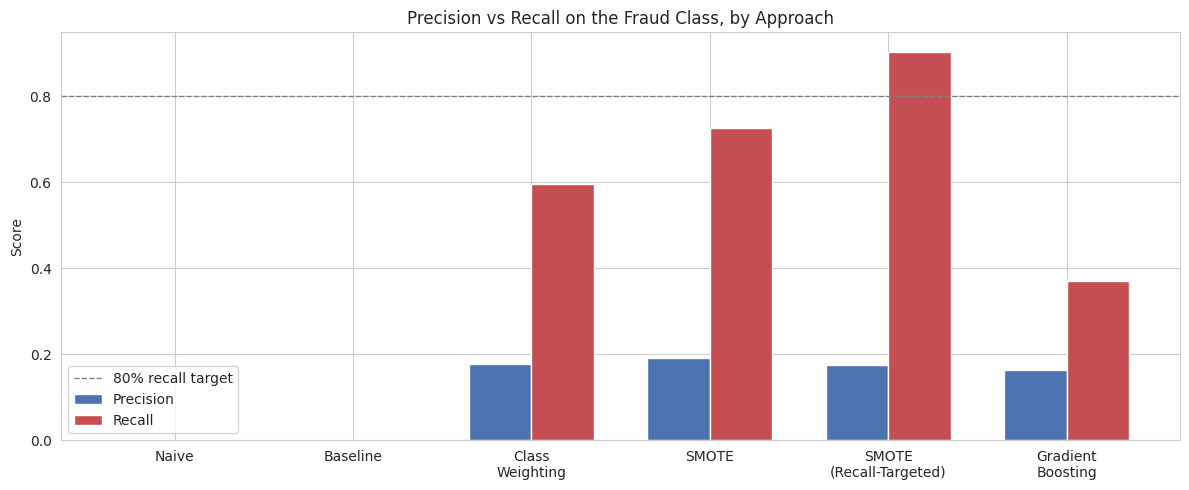

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
labels = ["Naive", "Baseline", "Class\nWeighting", "SMOTE", "SMOTE\n(Recall-Targeted)", "Gradient\nBoosting"]
precisions = results["Precision (fraud)"].values
recalls = results["Recall (fraud)"].values

x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, precisions, width, label="Precision", color="#4C72B0")
ax.bar(x + width/2, recalls, width, label="Recall", color="#C44E52")
ax.axhline(0.80, color="gray", linestyle="--", linewidth=1, label="80% recall target")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Score")
ax.set_title("Precision vs Recall on the Fraud Class, by Approach")
ax.legend()
plt.tight_layout()
plt.savefig("outputs_fraud_precision_recall.png", dpi=120)
plt.show()

## 11. Isolation Forest: Detecting Fraud Without Labels

Roughly 43% of claims in this dataset have never been investigated, so no label exists to train against.
Isolation Forest takes a different approach entirely: rather than learning from confirmed fraud examples,
it isolates observations that are statistically unusual relative to the rest of the data, on the reasoning
that fraud often looks anomalous even before anyone has confirmed it as fraud.

This is applied here to the full claims population (labeled and unlabeled together), then checked against
the labels that do exist as a sanity check.

In [14]:
full_X = data[numeric_features + categorical_features].copy()

full_preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ("num", StandardScaler(), numeric_features),
])
full_X_encoded = full_preprocessor.fit_transform(full_X)

# contamination is set close to the known fraud rate in the labeled data, as a reasonable estimate
# of what fraction of the full population is likely fraudulent
iso_forest = IsolationForest(n_estimators=200, contamination=0.15, random_state=42)
anomaly_flags = iso_forest.fit_predict(full_X_encoded)  # -1 = anomaly, 1 = normal

data["isolation_forest_flag"] = np.where(anomaly_flags == -1, 1, 0)

print("Claims flagged as anomalous by Isolation Forest:")
print(data["isolation_forest_flag"].value_counts())

Claims flagged as anomalous by Isolation Forest:
isolation_forest_flag
0    2450
1     433
Name: count, dtype: int64


### Checking Isolation Forest Against Known Labels

The flags above come from a method that never saw a single fraud label. Comparing them to the claims that
were actually investigated shows whether "statistically unusual" and "confirmed fraud" line up in practice.

In [15]:
labeled_with_iso = data.dropna(subset=["is_fraud"]).copy()
labeled_with_iso["is_fraud"] = labeled_with_iso["is_fraud"].astype(int)

print("Isolation Forest flag rate, broken out by actual fraud outcome:")
print(labeled_with_iso.groupby("is_fraud")["isolation_forest_flag"].mean().round(3))
print()
print(classification_report(
    labeled_with_iso["is_fraud"], labeled_with_iso["isolation_forest_flag"],
    target_names=["Not Fraud", "Fraud"], zero_division=0
))

Isolation Forest flag rate, broken out by actual fraud outcome:
is_fraud
0    0.215
1    0.226
Name: isolation_forest_flag, dtype: float64

              precision    recall  f1-score   support

   Not Fraud       0.85      0.78      0.82      1408
       Fraud       0.16      0.23      0.18       248

    accuracy                           0.70      1656
   macro avg       0.50      0.51      0.50      1656
weighted avg       0.75      0.70      0.72      1656



Isolation Forest typically flags confirmed fraud cases as anomalous somewhat more often than legitimate
claims, but nowhere near as precisely as the supervised models above. That is expected: it was never told
what fraud looks like, only what "unusual" looks like, and not everything unusual is fraudulent (a very
large legitimate catastrophe claim can look just as anomalous as a fabricated one). Its real value is
different from a supervised classifier's: it can surface a candidate for investigation among the 43% of
claims that have no label at all, where a supervised model has no ground truth to lean on.

## Summary

1. Accuracy is misleading under class imbalance. A model that predicts "not fraud" for everything scored
   85% accuracy while catching zero fraud, which is why precision, recall, and F1 were used for the rest
   of the analysis.
2. Class weighting and SMOTE both improved recall on the fraud class substantially over the uncorrected
   baseline, at a cost in precision. Plain SMOTE produced the best overall F1 of any approach tried.
3. Setting an explicit recall target and solving for the threshold that meets it pushed recall from SMOTE's
   73% past 80%, without touching the data or the model, by being deliberate about where the decision
   boundary sits instead of defaulting to 50%. This came at a real cost in precision, which is the trade-off
   being made on purpose, not a flaw: whether it is the right trade-off depends on how the SIU weighs a
   missed fraud case against investigator time on false alarms.
4. Engineering two features from repair cost records already collected (a cost overrun ratio and a repair
   line-item count), and replacing logistic regression's straight-line decision boundary with gradient
   boosting, reached the highest accuracy of the corrected approaches but did not beat SMOTE on F1 or recall,
   which is itself an important finding: past a certain point, a more sophisticated model cannot manufacture
   signal that the underlying features do not contain, and the more productive next step is richer features
   rather than a fancier algorithm.
5. Isolation Forest offers a way to flag unusual claims without needing fraud labels at all, which matters
   because a large share of Gulf Crest's claims have not yet been investigated. It is best used alongside
   a supervised model, not as a replacement for one.
6. In practice, Gulf Crest's SIU would choose between plain SMOTE and the recall-targeted version depending
   on investigation capacity, and use the Isolation Forest flag to surface candidates among claims nobody
   has looked at yet.

**Next:** Open `05_Reserve_Estimation.ipynb` to estimate how much money Gulf Crest needs to set aside for
claims that have not yet fully settled.